# PART A — SCIKIT-LEARN IMPLEMENTATION

In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("cleaned_productivity.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1197, 15)


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


Create MeetsTarget

In [3]:
df["MeetsTarget"] = (
    df["actual_productivity"] >= df["targeted_productivity"]
).astype(int)

In [4]:
print(df["MeetsTarget"].value_counts())
print(df["MeetsTarget"].value_counts(normalize=True))

MeetsTarget
1    875
0    322
Name: count, dtype: int64
MeetsTarget
1    0.730994
0    0.269006
Name: proportion, dtype: float64


Define regression and classification targets

In [5]:
y_reg = df["actual_productivity"]
y_clf = df["MeetsTarget"]

In [6]:
X = df.drop(columns=["actual_productivity", "MeetsTarget"])

In [7]:
X_reg = X.copy()
X_clf = X.copy()

Identify numerical and categorical features

In [8]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']

Categorical features:
['date', 'quarter', 'department', 'day']


In [9]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [11]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X,
    y_reg,
    y_clf,
    test_size=0.20,
    random_state=42
)

In [12]:
train_indices, test_indices = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42
)

In [13]:
X_train = X.loc[train_indices]
X_test = X.loc[test_indices]

y_reg_train = y_reg.loc[train_indices]
y_reg_test = y_reg.loc[test_indices]

y_clf_train = y_clf.loc[train_indices]
y_clf_test = y_clf.loc[test_indices]

Linear Regression

In [14]:
regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [15]:
start_time = time.perf_counter()

regression_model.fit(X_train, y_reg_train)

regression_train_time = time.perf_counter() - start_time

print(f"Linear Regression training time: {regression_train_time:.6f} seconds")

Linear Regression training time: 0.155152 seconds


Regression prediction

In [17]:
start_time = time.perf_counter()

y_reg_pred = regression_model.predict(X_test)

regression_prediction_time = time.perf_counter() - start_time

print(f"Linear Regression prediction time: {regression_prediction_time:.6f} seconds")

Linear Regression prediction time: 0.007354 seconds


Regression metrics

In [18]:
reg_mae = mean_absolute_error(y_reg_test, y_reg_pred)

reg_rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_reg_pred)
)

reg_r2 = r2_score(y_reg_test, y_reg_pred)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE  : {reg_mae:.4f}")
print(f"RMSE : {reg_rmse:.4f}")
print(f"R²   : {reg_r2:.4f}")

Linear Regression Results
-------------------------
MAE  : 0.1124
RMSE : 0.1500
R²   : 0.1521


Logistic Regression

In [19]:
classification_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [20]:
start_time = time.perf_counter()

classification_model.fit(X_train, y_clf_train)

classification_train_time = time.perf_counter() - start_time

print(
    f"Logistic Regression training time: "
    f"{classification_train_time:.6f} seconds"
)

Logistic Regression training time: 0.043161 seconds


In [21]:
start_time = time.perf_counter()

y_clf_pred = classification_model.predict(X_test)

classification_prediction_time = time.perf_counter() - start_time

print(
    f"Logistic Regression prediction time: "
    f"{classification_prediction_time:.6f} seconds"
)

Logistic Regression prediction time: 0.007989 seconds


In [22]:
clf_accuracy = accuracy_score(y_clf_test, y_clf_pred)

clf_precision = precision_score(
    y_clf_test,
    y_clf_pred,
    zero_division=0
)

clf_recall = recall_score(
    y_clf_test,
    y_clf_pred,
    zero_division=0
)

clf_f1 = f1_score(
    y_clf_test,
    y_clf_pred,
    zero_division=0
)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {clf_accuracy:.4f}")
print(f"Precision: {clf_precision:.4f}")
print(f"Recall   : {clf_recall:.4f}")
print(f"F1-score : {clf_f1:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.7417
Precision: 0.7700
Recall   : 0.9266
F1-score : 0.8410


In [23]:
sklearn_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Logistic Regression"
    ],
    
    "Train Time (s)": [
        regression_train_time,
        classification_train_time
    ],
    
    "Prediction Time (s)": [
        regression_prediction_time,
        classification_prediction_time
    ],
    
    "MAE": [
        reg_mae,
        np.nan
    ],
    
    "RMSE": [
        reg_rmse,
        np.nan
    ],
    
    "R2": [
        reg_r2,
        np.nan
    ],
    
    "Accuracy": [
        np.nan,
        clf_accuracy
    ],
    
    "Precision": [
        np.nan,
        clf_precision
    ],
    
    "Recall": [
        np.nan,
        clf_recall
    ],
    
    "F1": [
        np.nan,
        clf_f1
    ]
})

sklearn_results

,Model,Train Time (s),Prediction Time (s),MAE,RMSE,R2,Accuracy,Precision,Recall,F1
0,Linear Regression,0.155152,0.007354,0.112381,0.150048,0.152084,NaN,NaN,NaN,NaN
1,Logistic Regression,0.043161,0.007989,NaN,NaN,NaN,0.741667,0.769953,0.926554,0.841026


Confusion Matrix:
[[ 14  49]
 [ 13 164]]


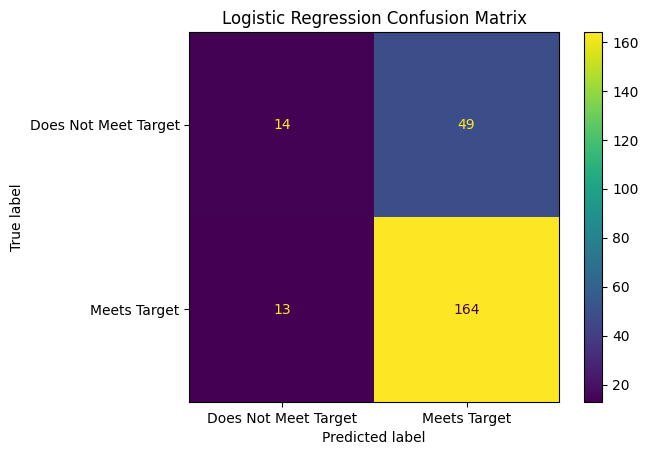

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns 

cm = confusion_matrix(y_clf_test, y_clf_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Does Not Meet Target", "Meets Target"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [26]:
y_clf_prob = classification_model.predict_proba(X_test)[:, 1]

print(y_clf_prob[:10])

[0.87466439 0.88892092 0.71295568 0.69784232 0.6352612  0.67703977
 0.49986848 0.61352454 0.91034763 0.94255061]


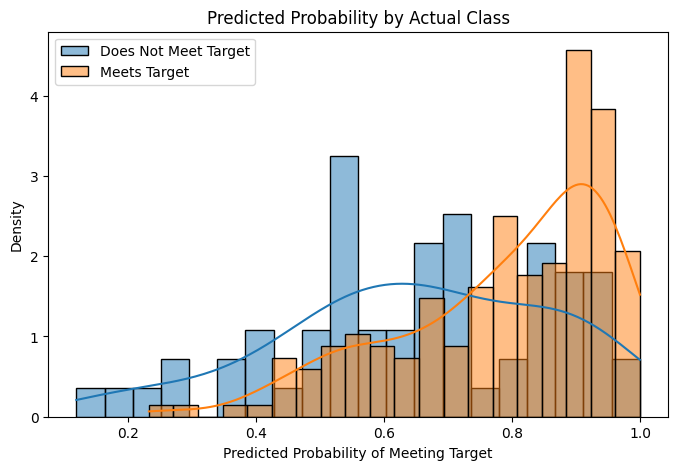

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(
    y_clf_prob[y_clf_test == 0],
    bins=20,
    kde=True,
    label="Does Not Meet Target",
    stat="density",
    alpha=0.5
)

sns.histplot(
    y_clf_prob[y_clf_test == 1],
    bins=20,
    kde=True,
    label="Meets Target",
    stat="density",
    alpha=0.5
)

plt.xlabel("Predicted Probability of Meeting Target")
plt.ylabel("Density")
plt.title("Predicted Probability by Actual Class")
plt.legend()
plt.show()

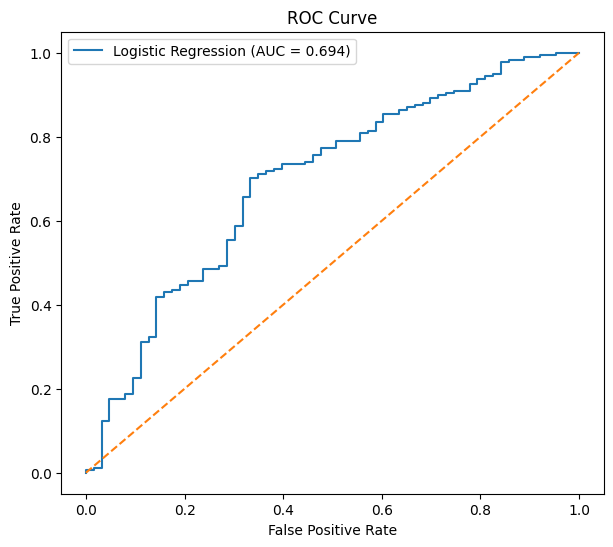

ROC-AUC: 0.6945


In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_clf_test,
    y_clf_prob
)

auc = roc_auc_score(
    y_clf_test,
    y_clf_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"ROC-AUC: {auc:.4f}")

In [29]:
fpr, tpr, thresholds = roc_curve(
    y_clf_test,
    y_clf_prob
)

In [30]:
youden_j = tpr - fpr

best_index = np.argmax(youden_j)

best_threshold = thresholds[best_index]

best_tpr = tpr[best_index]
best_fpr = fpr[best_index]

print("Best threshold:", best_threshold)
print("TPR:", best_tpr)
print("FPR:", best_fpr)
print("Youden's J:", youden_j[best_index])

Best threshold: 0.7329117698886296
TPR: 0.7005649717514124
FPR: 0.3333333333333333
Youden's J: 0.3672316384180791


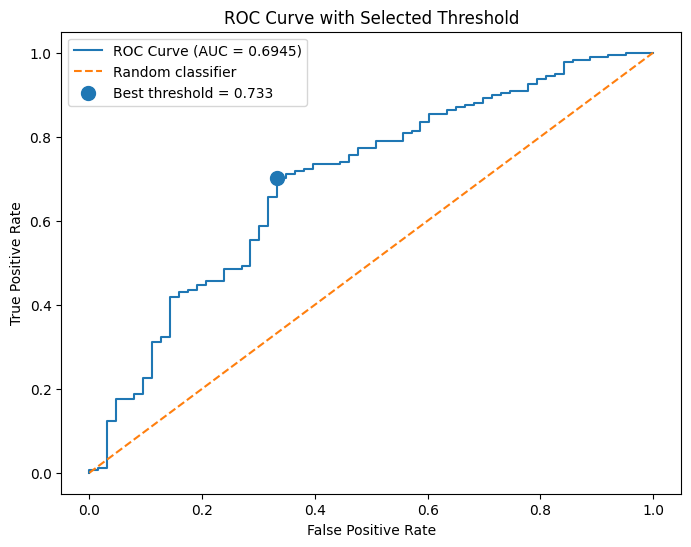

In [31]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.scatter(
    best_fpr,
    best_tpr,
    s=100,
    label=f"Best threshold = {best_threshold:.3f}"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Selected Threshold")
plt.legend()

plt.show()

In [32]:
y_clf_pred = classification_model.predict(X_test)

In [33]:
y_clf_pred_roc = (
    y_clf_prob >= best_threshold
).astype(int)

In [34]:
accuracy_roc = accuracy_score(
    y_clf_test,
    y_clf_pred_roc
)

precision_roc = precision_score(
    y_clf_test,
    y_clf_pred_roc,
    zero_division=0
)

recall_roc = recall_score(
    y_clf_test,
    y_clf_pred_roc,
    zero_division=0
)

f1_roc = f1_score(
    y_clf_test,
    y_clf_pred_roc,
    zero_division=0
)

print(f"ROC-based threshold: {best_threshold:.4f}")
print(f"Accuracy : {accuracy_roc:.4f}")
print(f"Precision: {precision_roc:.4f}")
print(f"Recall   : {recall_roc:.4f}")
print(f"F1-score : {f1_roc:.4f}")

ROC-based threshold: 0.7329
Accuracy : 0.6917
Precision: 0.8552
Recall   : 0.7006
F1-score : 0.7702


Linear regression residual analysis

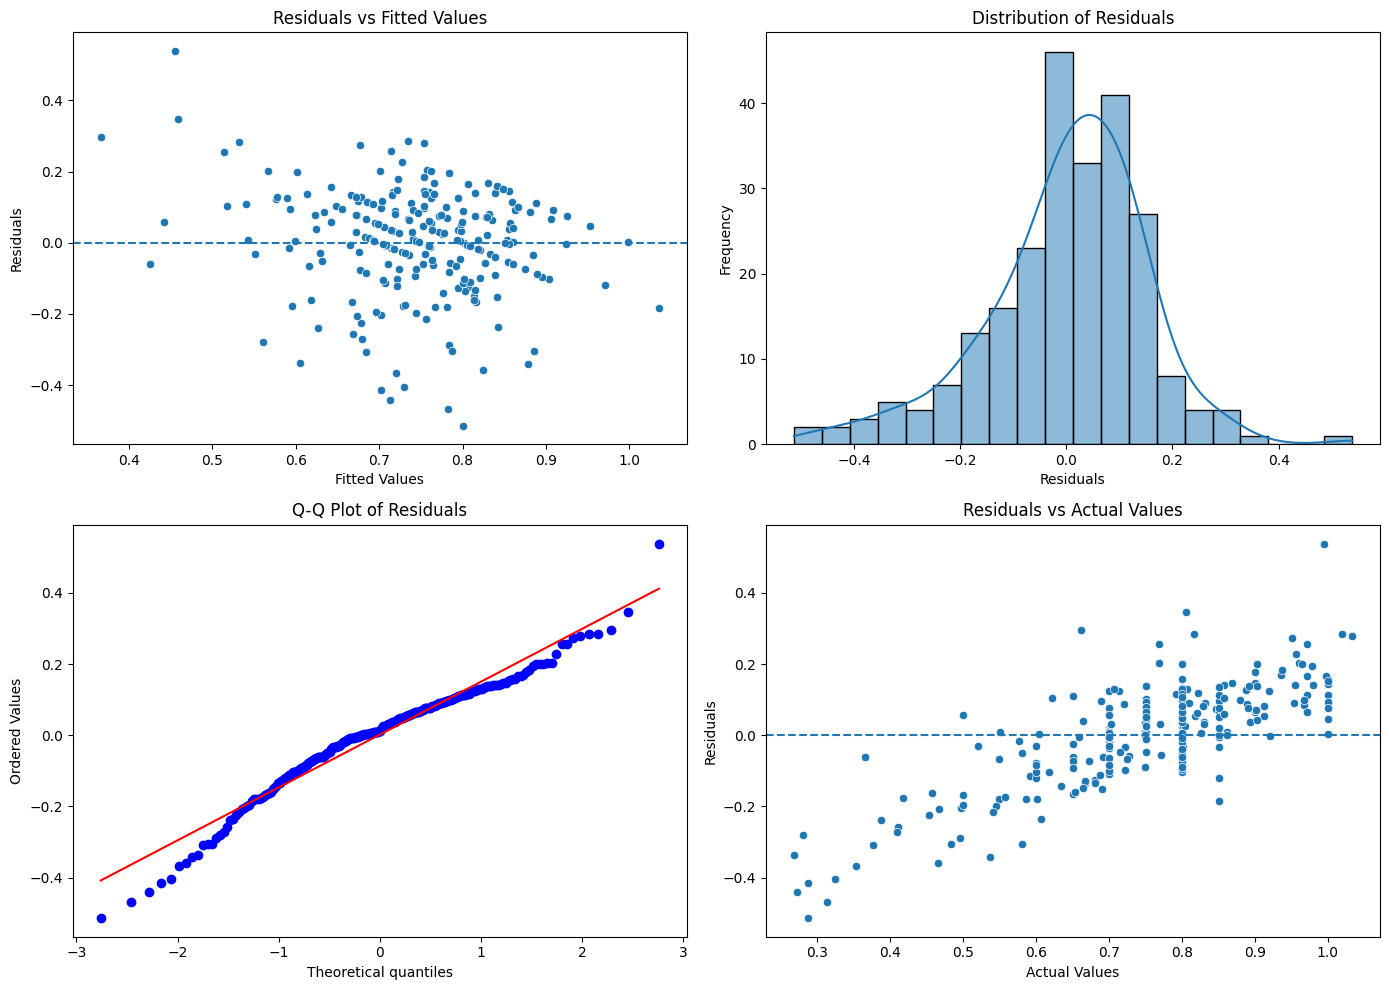

In [37]:
# Residuals
residuals = y_reg_test - y_reg_pred
fitted_values = y_reg_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --------------------------------
# 1. Residuals vs Fitted Values
# --------------------------------
sns.scatterplot(
    x=fitted_values,
    y=residuals,
    ax=axes[0, 0]
)
axes[0, 0].axhline(0, linestyle="--")
axes[0, 0].set_title("Residuals vs Fitted Values")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")

# --------------------------------
# 2. Distribution of Residuals
# --------------------------------
sns.histplot(
    residuals,
    kde=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Distribution of Residuals")
axes[0, 1].set_xlabel("Residuals")
axes[0, 1].set_ylabel("Frequency")

# --------------------------------
# 3. Q-Q Plot
# --------------------------------
stats.probplot(
    residuals,
    dist="norm",
    plot=axes[1, 0]
)
axes[1, 0].set_title("Q-Q Plot of Residuals")

# --------------------------------
# 4. Residuals vs Actual Values
# --------------------------------
sns.scatterplot(
    x=y_reg_test,
    y=residuals,
    ax=axes[1, 1]
)
axes[1, 1].axhline(0, linestyle="--")
axes[1, 1].set_title("Residuals vs Actual Values")
axes[1, 1].set_xlabel("Actual Values")
axes[1, 1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

# PART B — MANUAL IMPLEMENTATION

In [39]:
# ============================================================
# PART B — MANUAL IMPLEMENTATION
# ============================================================

# Copy the train and test data from Part A
X_train_manual = X_train.copy()
X_test_manual = X_test.copy()

# ------------------------------------------------------------
# Numerical features
# ------------------------------------------------------------

# Fill missing values using training-set median
train_medians = X_train_manual[numeric_features].median()

X_train_num = X_train_manual[numeric_features].copy()
X_test_num = X_test_manual[numeric_features].copy()

X_train_num = X_train_num.fillna(train_medians)
X_test_num = X_test_num.fillna(train_medians)

# Standardization using training-set mean and std
train_mean = X_train_num.mean()
train_std = X_train_num.std(ddof=0)

# Avoid division by zero
train_std = train_std.replace(0, 1)

X_train_num = (X_train_num - train_mean) / train_std
X_test_num = (X_test_num - train_mean) / train_std


# ------------------------------------------------------------
# Categorical features
# ------------------------------------------------------------

X_train_cat = X_train_manual[categorical_features].copy()
X_test_cat = X_test_manual[categorical_features].copy()

# Fill missing categorical values using training mode
for col in categorical_features:

    mode = X_train_cat[col].mode()[0]

    X_train_cat[col] = X_train_cat[col].fillna(mode)
    X_test_cat[col] = X_test_cat[col].fillna(mode)

# One-hot encoding
X_train_cat = pd.get_dummies(
    X_train_cat,
    columns=categorical_features,
    dtype=float
)

X_test_cat = pd.get_dummies(
    X_test_cat,
    columns=categorical_features,
    dtype=float
)

# Make test columns identical to training columns
X_test_cat = X_test_cat.reindex(
    columns=X_train_cat.columns,
    fill_value=0
)


# ------------------------------------------------------------
# Combine numerical + categorical features
# ------------------------------------------------------------

X_train_processed = pd.concat(
    [X_train_num, X_train_cat],
    axis=1
)

X_test_processed = pd.concat(
    [X_test_num, X_test_cat],
    axis=1
)

# Convert to NumPy
X_train_processed = X_train_processed.to_numpy(dtype=float)
X_test_processed = X_test_processed.to_numpy(dtype=float)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (957, 82)
Testing shape: (240, 82)


Add intercept

In [40]:
# Add column of 1s for intercept

X_train_manual = np.column_stack([
    np.ones(X_train_processed.shape[0]),
    X_train_processed
])

X_test_manual = np.column_stack([
    np.ones(X_test_processed.shape[0]),
    X_test_processed
])

print("Final training matrix:", X_train_manual.shape)
print("Final testing matrix:", X_test_manual.shape)

Final training matrix: (957, 83)
Final testing matrix: (240, 83)


Manual Linear Regression

In [41]:
# ============================================================
# MANUAL LINEAR REGRESSION
# ============================================================

start_time = time.perf_counter()

XtX = X_train_manual.T @ X_train_manual
Xty = X_train_manual.T @ y_reg_train.to_numpy()

beta_manual = np.linalg.pinv(XtX) @ Xty

manual_reg_train_time = time.perf_counter() - start_time

In [43]:
start_time = time.perf_counter()

y_reg_pred_manual = X_test_manual @ beta_manual

manual_reg_prediction_time = time.perf_counter() - start_time

In [44]:
# Residuals
reg_residuals = y_reg_test.to_numpy() - y_reg_pred_manual

# MAE
manual_mae = np.mean(np.abs(reg_residuals))

# RMSE
manual_rmse = np.sqrt(np.mean(reg_residuals ** 2))

# R²
ss_res = np.sum(reg_residuals ** 2)

ss_tot = np.sum(
    (y_reg_test.to_numpy() - y_reg_test.mean()) ** 2
)

manual_r2 = 1 - (ss_res / ss_tot)

print("MANUAL LINEAR REGRESSION")
print("------------------------")
print("MAE :", manual_mae)
print("RMSE:", manual_rmse)
print("R²  :", manual_r2)
print("Train time     :", manual_reg_train_time)
print("Prediction time:", manual_reg_prediction_time)

MANUAL LINEAR REGRESSION
------------------------
MAE : 0.11238111278338479
RMSE: 0.1500482193646943
R²  : 0.15207620676266975
Train time     : 0.0055078000004868954
Prediction time: 0.00018450000789016485


Manual Logistic Regression

Logistic prediction

In [51]:
# Manual Logistic Regression - Prediction using Part A threshold

start_time = time.perf_counter()

# 1. Calculate predicted probabilities
logit = X_test_manual @ beta_logistic_manual
y_clf_prob_manual = sigmoid(logit)

# 2. Use the same best threshold from Part A
best_threshold = 0.7329

# 3. Convert probabilities into class predictions
y_clf_pred_manual = (
    y_clf_prob_manual >= best_threshold
).astype(int)

manual_clf_prediction_time = time.perf_counter() - start_time


# 4. Calculate classification metrics manually
y_true = y_clf_test.to_numpy()

TP = np.sum((y_true == 1) & (y_clf_pred_manual == 1))
TN = np.sum((y_true == 0) & (y_clf_pred_manual == 0))
FP = np.sum((y_true == 0) & (y_clf_pred_manual == 1))
FN = np.sum((y_true == 1) & (y_clf_pred_manual == 0))

manual_accuracy = (TP + TN) / (TP + TN + FP + FN)

manual_precision = (
    TP / (TP + FP)
    if (TP + FP) > 0 else 0
)

manual_recall = (
    TP / (TP + FN)
    if (TP + FN) > 0 else 0
)

manual_f1 = (
    2 * manual_precision * manual_recall /
    (manual_precision + manual_recall)
    if (manual_precision + manual_recall) > 0 else 0
)


# 5. Display results
print("MANUAL LOGISTIC REGRESSION")
print("--------------------------")
print("Threshold :", best_threshold)
print("Accuracy  :", manual_accuracy)
print("Precision :", manual_precision)
print("Recall    :", manual_recall)
print("F1 Score  :", manual_f1)
print("Prediction time:", manual_clf_prediction_time)

MANUAL LOGISTIC REGRESSION
--------------------------
Threshold : 0.7329
Accuracy  : 0.675
Precision : 0.8413793103448276
Recall    : 0.6892655367231638
F1 Score  : 0.7577639751552795
Prediction time: 0.00038150002365000546


In [53]:
# Manual Logistic Regression - Training

start_time = time.perf_counter()

beta_logistic_manual = logistic_regression_manual(
    X_train_manual,
    y_clf_train.to_numpy(),
    learning_rate=0.01,
    epochs=10000
)

manual_clf_train_time = time.perf_counter() - start_time

print("Manual Logistic Regression trained successfully.")
print("Training time:", manual_clf_train_time)
print("Number of coefficients:", len(beta_logistic_manual))

Manual Logistic Regression trained successfully.
Training time: 0.3661061000020709
Number of coefficients: 83


In [54]:
# Manual Logistic Regression - Prediction

start_time = time.perf_counter()

logit = X_test_manual @ beta_logistic_manual
y_clf_prob_manual = sigmoid(logit)

best_threshold = 0.7329

y_clf_pred_manual = (
    y_clf_prob_manual >= best_threshold
).astype(int)

manual_clf_prediction_time = time.perf_counter() - start_time

print("Prediction completed.")
print("Threshold:", best_threshold)
print("Prediction time:", manual_clf_prediction_time)

Prediction completed.
Threshold: 0.7329
Prediction time: 0.0002908000024035573


In [55]:
# Part B - Sklearn vs Manual Comparison

# Sklearn predictions using the same threshold as manual model
y_clf_pred_sklearn_threshold = (
    y_clf_prob >= 0.7329
).astype(int)

# Sklearn classification metrics at threshold 0.7329
sklearn_accuracy_threshold = accuracy_score(
    y_clf_test, y_clf_pred_sklearn_threshold
)

sklearn_precision_threshold = precision_score(
    y_clf_test, y_clf_pred_sklearn_threshold, zero_division=0
)

sklearn_recall_threshold = recall_score(
    y_clf_test, y_clf_pred_sklearn_threshold, zero_division=0
)

sklearn_f1_threshold = f1_score(
    y_clf_test, y_clf_pred_sklearn_threshold, zero_division=0
)


# Comparison table
comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Logistic Regression"
    ],

    "Sklearn Train Time": [
        regression_train_time,
        classification_train_time
    ],

    "Manual Train Time": [
        manual_reg_train_time,
        manual_clf_train_time
    ],

    "Sklearn Prediction Time": [
        regression_prediction_time,
        classification_prediction_time
    ],

    "Manual Prediction Time": [
        manual_reg_prediction_time,
        manual_clf_prediction_time
    ],

    "Sklearn MAE": [
        reg_mae,
        np.nan
    ],

    "Manual MAE": [
        manual_mae,
        np.nan
    ],

    "Sklearn RMSE": [
        reg_rmse,
        np.nan
    ],

    "Manual RMSE": [
        manual_rmse,
        np.nan
    ],

    "Sklearn R²": [
        reg_r2,
        np.nan
    ],

    "Manual R²": [
        manual_r2,
        np.nan
    ],

    "Sklearn Accuracy": [
        np.nan,
        sklearn_accuracy_threshold
    ],

    "Manual Accuracy": [
        np.nan,
        manual_accuracy
    ],

    "Sklearn Precision": [
        np.nan,
        sklearn_precision_threshold
    ],

    "Manual Precision": [
        np.nan,
        manual_precision
    ],

    "Sklearn Recall": [
        np.nan,
        sklearn_recall_threshold
    ],

    "Manual Recall": [
        np.nan,
        manual_recall
    ],

    "Sklearn F1": [
        np.nan,
        sklearn_f1_threshold
    ],

    "Manual F1": [
        np.nan,
        manual_f1
    ]
})

comparison

,Model,Sklearn Train Time,Manual Train Time,Sklearn Prediction Time,Manual Prediction Time,Sklearn MAE,Manual MAE,Sklearn RMSE,Manual RMSE,Sklearn R²,Manual R²,Sklearn Accuracy,Manual Accuracy,Sklearn Precision,Manual Precision,Sklearn Recall,Manual Recall,Sklearn F1,Manual F1
0,Linear Regression,0.155152,0.005508,0.007354,0.000185,0.112381,0.112381,0.150048,0.150048,0.152084,0.152076,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Logistic Regression,0.043161,0.366106,0.007989,0.000291,NaN,NaN,NaN,NaN,NaN,NaN,0.691667,0.675,0.855172,0.841379,0.700565,0.689266,0.770186,0.757764


# Part C - Optimized Manual Logistic Regression

In [56]:
# Part C - Optimized Manual Logistic Regression
# Optimization: Early Stopping

def logistic_regression_optimized(
    X,
    y,
    learning_rate=0.01,
    max_epochs=10000,
    tolerance=1e-7
):
    n_samples, n_features = X.shape
    beta = np.zeros(n_features)

    previous_loss = np.inf

    for epoch in range(max_epochs):

        # Calculate probabilities
        z = X @ beta
        probability = sigmoid(z)

        # Gradient
        gradient = (X.T @ (probability - y)) / n_samples

        # Update coefficients
        beta = beta - learning_rate * gradient

        # Calculate log-loss
        probability_clipped = np.clip(
            probability, 1e-15, 1 - 1e-15
        )

        loss = -np.mean(
            y * np.log(probability_clipped)
            + (1 - y) * np.log(1 - probability_clipped)
        )

        # Early stopping
        if abs(previous_loss - loss) < tolerance:
            break

        previous_loss = loss

    return beta, epoch + 1

In [57]:
# Train optimized manual logistic regression

start_time = time.perf_counter()

beta_logistic_optimized, epochs_used = logistic_regression_optimized(
    X_train_manual,
    y_clf_train.to_numpy(),
    learning_rate=0.01,
    max_epochs=10000,
    tolerance=1e-7
)

optimized_clf_train_time = time.perf_counter() - start_time

print("Optimized Logistic Regression")
print("-----------------------------")
print("Training time :", optimized_clf_train_time)
print("Epochs used   :", epochs_used)

Optimized Logistic Regression
-----------------------------
Training time : 0.8194507999869529
Epochs used   : 10000


In [58]:
# Part C - Optimized Manual Logistic Regression Prediction

start_time = time.perf_counter()

# Predicted probabilities
logit_optimized = X_test_manual @ beta_logistic_optimized
y_clf_prob_optimized = sigmoid(logit_optimized)

# Same threshold used in Part A and Part B
best_threshold = 0.7329

# Convert probabilities to classes
y_clf_pred_optimized = (
    y_clf_prob_optimized >= best_threshold
).astype(int)

optimized_clf_prediction_time = time.perf_counter() - start_time


# Actual values
y_true = y_clf_test.to_numpy()

# Confusion matrix components
TP = np.sum((y_true == 1) & (y_clf_pred_optimized == 1))
TN = np.sum((y_true == 0) & (y_clf_pred_optimized == 0))
FP = np.sum((y_true == 0) & (y_clf_pred_optimized == 1))
FN = np.sum((y_true == 1) & (y_clf_pred_optimized == 0))

# Metrics
optimized_accuracy = (TP + TN) / (TP + TN + FP + FN)

optimized_precision = (
    TP / (TP + FP)
    if (TP + FP) > 0 else 0
)

optimized_recall = (
    TP / (TP + FN)
    if (TP + FN) > 0 else 0
)

optimized_f1 = (
    2 * optimized_precision * optimized_recall /
    (optimized_precision + optimized_recall)
    if (optimized_precision + optimized_recall) > 0 else 0
)


print("OPTIMIZED MANUAL LOGISTIC REGRESSION")
print("------------------------------------")
print("Threshold       :", best_threshold)
print("Accuracy        :", optimized_accuracy)
print("Precision       :", optimized_precision)
print("Recall          :", optimized_recall)
print("F1 Score        :", optimized_f1)
print("Prediction time :", optimized_clf_prediction_time)

OPTIMIZED MANUAL LOGISTIC REGRESSION
------------------------------------
Threshold       : 0.7329
Accuracy        : 0.675
Precision       : 0.8413793103448276
Recall          : 0.6892655367231638
F1 Score        : 0.7577639751552795
Prediction time : 0.000319099985063076


In [59]:
# Part C - Logistic Regression Comparison
# Sklearn vs Original Manual vs Optimized Manual

logistic_comparison = pd.DataFrame({

    "Implementation": [
        "Sklearn",
        "Manual",
        "Optimized Manual"
    ],

    "Train Time (s)": [
        classification_train_time,
        manual_clf_train_time,
        optimized_clf_train_time
    ],

    "Prediction Time (s)": [
        classification_prediction_time,
        manual_clf_prediction_time,
        optimized_clf_prediction_time
    ],

    "Accuracy": [
        sklearn_accuracy_threshold,
        manual_accuracy,
        optimized_accuracy
    ],

    "Precision": [
        sklearn_precision_threshold,
        manual_precision,
        optimized_precision
    ],

    "Recall": [
        sklearn_recall_threshold,
        manual_recall,
        optimized_recall
    ],

    "F1 Score": [
        sklearn_f1_threshold,
        manual_f1,
        optimized_f1
    ]
})

logistic_comparison

,Implementation,Train Time (s),Prediction Time (s),Accuracy,Precision,Recall,F1 Score
0,Sklearn,0.043161,0.007989,0.691667,0.855172,0.700565,0.770186
1,Manual,0.366106,0.000291,0.675000,0.841379,0.689266,0.757764
2,Optimized Manual,0.819451,0.000319,0.675000,0.841379,0.689266,0.757764


In [60]:
# Training time improvement

original_time = manual_clf_train_time
optimized_time = optimized_clf_train_time

time_reduction = (
    (original_time - optimized_time) / original_time
) * 100

print("Original Manual Training Time :", original_time)
print("Optimized Training Time       :", optimized_time)
print("Training Time Reduction       :", time_reduction, "%")

Original Manual Training Time : 0.3661061000020709
Optimized Training Time       : 0.8194507999869529
Training Time Reduction       : -123.82877531467453 %


In [61]:
# Part C - Optimized Manual Logistic Regression
# Optimization: Higher Learning Rate + Early Stopping

def logistic_regression_optimized(
    X,
    y,
    learning_rate=0.1,
    max_epochs=3000,
    tolerance=1e-6
):
    n_samples, n_features = X.shape
    beta = np.zeros(n_features)

    previous_loss = np.inf

    for epoch in range(max_epochs):

        # Forward pass
        z = X @ beta
        probability = sigmoid(z)

        # Gradient
        gradient = (X.T @ (probability - y)) / n_samples

        # Update coefficients
        beta = beta - learning_rate * gradient

        # Calculate loss only for convergence checking
        new_probability = sigmoid(X @ beta)
        new_probability = np.clip(
            new_probability, 1e-15, 1 - 1e-15
        )

        loss = -np.mean(
            y * np.log(new_probability)
            + (1 - y) * np.log(1 - new_probability)
        )

        # Early stopping
        if abs(previous_loss - loss) < tolerance:
            break

        previous_loss = loss

    return beta, epoch + 1

In [62]:
# Train optimized model

start_time = time.perf_counter()

beta_logistic_optimized, epochs_used = logistic_regression_optimized(
    X_train_manual,
    y_clf_train.to_numpy(),
    learning_rate=0.1,
    max_epochs=3000,
    tolerance=1e-6
)

optimized_clf_train_time = time.perf_counter() - start_time

print("Optimized Logistic Regression")
print("-----------------------------")
print("Training time :", optimized_clf_train_time)
print("Epochs used   :", epochs_used)

Optimized Logistic Regression
-----------------------------
Training time : 0.338755000004312
Epochs used   : 3000


In [63]:
# Part C - Evaluate Optimized Logistic Regression

start_time = time.perf_counter()

# Predicted probabilities
logit_optimized = X_test_manual @ beta_logistic_optimized
y_clf_prob_optimized = sigmoid(logit_optimized)

# Same threshold used in Part A and Part B
best_threshold = 0.7329

# Class predictions
y_clf_pred_optimized = (
    y_clf_prob_optimized >= best_threshold
).astype(int)

optimized_clf_prediction_time = time.perf_counter() - start_time


# Actual values
y_true = y_clf_test.to_numpy()

# Confusion matrix components
TP = np.sum((y_true == 1) & (y_clf_pred_optimized == 1))
TN = np.sum((y_true == 0) & (y_clf_pred_optimized == 0))
FP = np.sum((y_true == 0) & (y_clf_pred_optimized == 1))
FN = np.sum((y_true == 1) & (y_clf_pred_optimized == 0))

# Metrics
optimized_accuracy = (TP + TN) / (TP + TN + FP + FN)

optimized_precision = (
    TP / (TP + FP) if (TP + FP) > 0 else 0
)

optimized_recall = (
    TP / (TP + FN) if (TP + FN) > 0 else 0
)

optimized_f1 = (
    2 * optimized_precision * optimized_recall /
    (optimized_precision + optimized_recall)
    if (optimized_precision + optimized_recall) > 0 else 0
)


# Display results
print("OPTIMIZED MANUAL LOGISTIC REGRESSION")
print("------------------------------------")
print("Threshold       :", best_threshold)
print("Epochs used     :", epochs_used)
print("Accuracy        :", optimized_accuracy)
print("Precision       :", optimized_precision)
print("Recall          :", optimized_recall)
print("F1 Score        :", optimized_f1)
print("Prediction time :", optimized_clf_prediction_time)

OPTIMIZED MANUAL LOGISTIC REGRESSION
------------------------------------
Threshold       : 0.7329
Epochs used     : 3000
Accuracy        : 0.6916666666666667
Precision       : 0.8503401360544217
Recall          : 0.7062146892655368
F1 Score        : 0.771604938271605
Prediction time : 0.0003640999784693122


In [64]:
# Part C - Final Logistic Regression Comparison

logistic_comparison = pd.DataFrame({

    "Implementation": [
        "Sklearn",
        "Manual",
        "Optimized Manual"
    ],

    "Train Time (s)": [
        classification_train_time,
        manual_clf_train_time,
        optimized_clf_train_time
    ],

    "Prediction Time (s)": [
        classification_prediction_time,
        manual_clf_prediction_time,
        optimized_clf_prediction_time
    ],

    "Accuracy": [
        sklearn_accuracy_threshold,
        manual_accuracy,
        optimized_accuracy
    ],

    "Precision": [
        sklearn_precision_threshold,
        manual_precision,
        optimized_precision
    ],

    "Recall": [
        sklearn_recall_threshold,
        manual_recall,
        optimized_recall
    ],

    "F1 Score": [
        sklearn_f1_threshold,
        manual_f1,
        optimized_f1
    ]
})

logistic_comparison

,Implementation,Train Time (s),Prediction Time (s),Accuracy,Precision,Recall,F1 Score
0,Sklearn,0.043161,0.007989,0.691667,0.855172,0.700565,0.770186
1,Manual,0.366106,0.000291,0.675000,0.841379,0.689266,0.757764
2,Optimized Manual,0.338755,0.000364,0.691667,0.850340,0.706215,0.771605


In [65]:
# Part C - Optimized Logistic Regression Prediction
# Optimization: Avoid unnecessary sigmoid calculation

best_threshold = 0.7329

start_time = time.perf_counter()

# Calculate logits directly
logit_optimized = X_test_manual @ beta_logistic_optimized

# Convert probability threshold to logit threshold
logit_threshold = np.log(
    best_threshold / (1 - best_threshold)
)

# Direct classification without calculating sigmoid
y_clf_pred_optimized = (
    logit_optimized >= logit_threshold
).astype(int)

optimized_clf_prediction_time = time.perf_counter() - start_time


# Calculate probabilities separately only if needed
y_clf_prob_optimized = sigmoid(logit_optimized)


print("OPTIMIZED MANUAL LOGISTIC REGRESSION")
print("------------------------------------")
print("Probability threshold :", best_threshold)
print("Logit threshold       :", logit_threshold)
print("Prediction time       :", optimized_clf_prediction_time)

OPTIMIZED MANUAL LOGISTIC REGRESSION
------------------------------------
Probability threshold : 0.7329
Logit threshold       : 1.0093861468158891
Prediction time       : 0.00025409998488612473


In [66]:
# Metrics for optimized prediction

y_true = y_clf_test.to_numpy()

TP = np.sum((y_true == 1) & (y_clf_pred_optimized == 1))
TN = np.sum((y_true == 0) & (y_clf_pred_optimized == 0))
FP = np.sum((y_true == 0) & (y_clf_pred_optimized == 1))
FN = np.sum((y_true == 1) & (y_clf_pred_optimized == 0))

optimized_accuracy = (TP + TN) / len(y_true)

optimized_precision = (
    TP / (TP + FP) if (TP + FP) > 0 else 0
)

optimized_recall = (
    TP / (TP + FN) if (TP + FN) > 0 else 0
)

optimized_f1 = (
    2 * optimized_precision * optimized_recall /
    (optimized_precision + optimized_recall)
    if (optimized_precision + optimized_recall) > 0 else 0
)

print("Accuracy  :", optimized_accuracy)
print("Precision :", optimized_precision)
print("Recall    :", optimized_recall)
print("F1 Score  :", optimized_f1)

Accuracy  : 0.6916666666666667
Precision : 0.8503401360544217
Recall    : 0.7062146892655368
F1 Score  : 0.771604938271605


In [67]:
# Part C - Prediction Time Benchmark
# Average prediction time over multiple runs

import time
import numpy as np

n_runs = 1000

# -----------------------------
# Original Manual Prediction
# -----------------------------
start_time = time.perf_counter()

for _ in range(n_runs):
    logit_original = X_test_manual @ beta_logistic_manual
    probability_original = sigmoid(logit_original)
    prediction_original = (
        probability_original >= 0.7329
    ).astype(int)

original_total_time = time.perf_counter() - start_time
original_avg_time = original_total_time / n_runs


# -----------------------------
# Optimized Manual Prediction
# -----------------------------
logit_threshold = np.log(
    0.7329 / (1 - 0.7329)
)

start_time = time.perf_counter()

for _ in range(n_runs):
    logit_optimized = X_test_manual @ beta_logistic_optimized
    prediction_optimized = (
        logit_optimized >= logit_threshold
    ).astype(int)

optimized_total_time = time.perf_counter() - start_time
optimized_avg_time = optimized_total_time / n_runs


# -----------------------------
# Results
# -----------------------------
print("PREDICTION TIME BENCHMARK")
print("--------------------------")
print("Number of runs:", n_runs)

print("\nOriginal Manual:")
print("Total time   :", original_total_time)
print("Average time :", original_avg_time)

print("\nOptimized Manual:")
print("Total time   :", optimized_total_time)
print("Average time :", optimized_avg_time)

print("\nPrediction time reduction:")
print(
    ((original_avg_time - optimized_avg_time)
     / original_avg_time) * 100,
    "%"
)

PREDICTION TIME BENCHMARK
--------------------------
Number of runs: 1000

Original Manual:
Total time   : 0.026683100004447624
Average time : 2.6683100004447623e-05

Optimized Manual:
Total time   : 0.00657830000272952
Average time : 6.57830000272952e-06

Prediction time reduction:
75.34656767154854 %


In [68]:
# Part C - Final Logistic Regression Comparison

logistic_part_c = pd.DataFrame({
    "Implementation": [
        "Sklearn",
        "Manual",
        "Optimized Manual"
    ],

    "Train Time (s)": [
        classification_train_time,
        manual_clf_train_time,
        optimized_clf_train_time
    ],

    "Prediction Time (s)": [
        classification_prediction_time,
        original_avg_time,
        optimized_avg_time
    ],

    "Accuracy": [
        sklearn_accuracy_threshold,
        manual_accuracy,
        optimized_accuracy
    ],

    "Precision": [
        sklearn_precision_threshold,
        manual_precision,
        optimized_precision
    ],

    "Recall": [
        sklearn_recall_threshold,
        manual_recall,
        optimized_recall
    ],

    "F1 Score": [
        sklearn_f1_threshold,
        manual_f1,
        optimized_f1
    ]
})

logistic_part_c

,Implementation,Train Time (s),Prediction Time (s),Accuracy,Precision,Recall,F1 Score
0,Sklearn,0.043161,0.007989,0.691667,0.855172,0.700565,0.770186
1,Manual,0.366106,0.000027,0.675000,0.841379,0.689266,0.757764
2,Optimized Manual,0.338755,0.000007,0.691667,0.850340,0.706215,0.771605


# Part C - Optimized Manual Linear Regression

In [69]:
# Part C - Optimized Manual Linear Regression
# Optimization: np.linalg.solve instead of pseudoinverse

start_time = time.perf_counter()

XtX = X_train_manual.T @ X_train_manual
Xty = X_train_manual.T @ y_reg_train.to_numpy()

beta_linear_optimized = np.linalg.solve(XtX, Xty)

optimized_reg_train_time = time.perf_counter() - start_time


# Prediction
start_time = time.perf_counter()

y_reg_pred_optimized = X_test_manual @ beta_linear_optimized

optimized_reg_prediction_time = time.perf_counter() - start_time


# Metrics
residuals_optimized = (
    y_reg_test.to_numpy() - y_reg_pred_optimized
)

optimized_mae = np.mean(
    np.abs(residuals_optimized)
)

optimized_rmse = np.sqrt(
    np.mean(residuals_optimized ** 2)
)

ss_res = np.sum(residuals_optimized ** 2)

ss_tot = np.sum(
    (y_reg_test.to_numpy() - y_reg_test.mean()) ** 2
)

optimized_r2 = 1 - (ss_res / ss_tot)


print("OPTIMIZED MANUAL LINEAR REGRESSION")
print("----------------------------------")
print("MAE :", optimized_mae)
print("RMSE:", optimized_rmse)
print("R²  :", optimized_r2)
print("Train time     :", optimized_reg_train_time)
print("Prediction time:", optimized_reg_prediction_time)

OPTIMIZED MANUAL LINEAR REGRESSION
----------------------------------
MAE : 0.11238111278338539
RMSE: 0.15004821936469445
R²  : 0.1520762067626681
Train time     : 0.0014085000148043036
Prediction time: 0.00011610001092776656


In [70]:
# Part C - Linear Regression Comparison
# Sklearn vs Original Manual vs Optimized Manual

linear_part_c = pd.DataFrame({

    "Implementation": [
        "Sklearn",
        "Manual",
        "Optimized Manual"
    ],

    "Train Time (s)": [
        regression_train_time,
        manual_reg_train_time,
        optimized_reg_train_time
    ],

    "Prediction Time (s)": [
        regression_prediction_time,
        manual_reg_prediction_time,
        optimized_reg_prediction_time
    ],

    "MAE": [
        reg_mae,
        manual_mae,
        optimized_mae
    ],

    "RMSE": [
        reg_rmse,
        manual_rmse,
        optimized_rmse
    ],

    "R²": [
        reg_r2,
        manual_r2,
        optimized_r2
    ]
})

linear_part_c

,Implementation,Train Time (s),Prediction Time (s),MAE,RMSE,R²
0,Sklearn,0.155152,0.007354,0.112381,0.150048,0.152084
1,Manual,0.005508,0.000185,0.112381,0.150048,0.152076
2,Optimized Manual,0.001409,0.000116,0.112381,0.150048,0.152076


In [71]:
# Linear Regression optimization improvement

train_reduction = (
    (manual_reg_train_time - optimized_reg_train_time)
    / manual_reg_train_time
) * 100

prediction_reduction = (
    (manual_reg_prediction_time - optimized_reg_prediction_time)
    / manual_reg_prediction_time
) * 100

print("Training time reduction   :", train_reduction, "%")
print("Prediction time reduction :", prediction_reduction, "%")

Training time reduction   : 74.42717573841115 %
Prediction time reduction : 37.07316749987223 %


In [72]:
# Part C - Optimized Manual Logistic Regression
# Optimization: Gradient Descent + Momentum

def logistic_regression_momentum(
    X,
    y,
    learning_rate=0.1,
    momentum=0.9,
    max_epochs=1000,
    tolerance=1e-6
):
    n_samples, n_features = X.shape

    # Initialize coefficients
    beta = np.zeros(n_features)

    # Initialize velocity
    velocity = np.zeros(n_features)

    previous_loss = np.inf

    for epoch in range(max_epochs):

        # Forward pass
        z = X @ beta
        probability = sigmoid(z)

        # Gradient
        gradient = (
            X.T @ (probability - y)
        ) / n_samples

        # Momentum update
        velocity = (
            momentum * velocity
            + learning_rate * gradient
        )

        beta = beta - velocity

        # Check convergence only every 20 epochs
        # to avoid unnecessary loss calculations
        if epoch % 20 == 0:

            p = np.clip(
                sigmoid(X @ beta),
                1e-15,
                1 - 1e-15
            )

            loss = -np.mean(
                y * np.log(p)
                + (1 - y) * np.log(1 - p)
            )

            if abs(previous_loss - loss) < tolerance:
                break

            previous_loss = loss

    return beta, epoch + 1

In [73]:
# Train optimized Logistic Regression

start_time = time.perf_counter()

beta_logistic_optimized, optimized_epochs = (
    logistic_regression_momentum(
        X_train_manual,
        y_clf_train.to_numpy(),
        learning_rate=0.1,
        momentum=0.9,
        max_epochs=1000,
        tolerance=1e-6
    )
)

optimized_clf_train_time = (
    time.perf_counter() - start_time
)

print("OPTIMIZED MANUAL LOGISTIC REGRESSION")
print("------------------------------------")
print("Training time :", optimized_clf_train_time)
print("Epochs used   :", optimized_epochs)

OPTIMIZED MANUAL LOGISTIC REGRESSION
------------------------------------
Training time : 0.06044319999637082
Epochs used   : 1000


In [74]:
# Evaluate optimized Logistic Regression

best_threshold = 0.7329

logit_optimized = (
    X_test_manual @ beta_logistic_optimized
)

y_clf_prob_optimized = sigmoid(logit_optimized)

y_clf_pred_optimized = (
    y_clf_prob_optimized >= best_threshold
).astype(int)


# Metrics
y_true = y_clf_test.to_numpy()

TP = np.sum(
    (y_true == 1) & (y_clf_pred_optimized == 1)
)

TN = np.sum(
    (y_true == 0) & (y_clf_pred_optimized == 0)
)

FP = np.sum(
    (y_true == 0) & (y_clf_pred_optimized == 1)
)

FN = np.sum(
    (y_true == 1) & (y_clf_pred_optimized == 0)
)

optimized_accuracy = (
    (TP + TN) / len(y_true)
)

optimized_precision = (
    TP / (TP + FP)
    if (TP + FP) > 0 else 0
)

optimized_recall = (
    TP / (TP + FN)
    if (TP + FN) > 0 else 0
)

optimized_f1 = (
    2 * optimized_precision * optimized_recall /
    (optimized_precision + optimized_recall)
    if (optimized_precision + optimized_recall) > 0
    else 0
)


print("Accuracy :", optimized_accuracy)
print("Precision:", optimized_precision)
print("Recall   :", optimized_recall)
print("F1 Score :", optimized_f1)

Accuracy : 0.6791666666666667
Precision: 0.8378378378378378
Recall   : 0.7005649717514124
F1 Score : 0.763076923076923


In [75]:
print("Sklearn training time :", classification_train_time)
print("Original manual time  :", manual_clf_train_time)
print("Optimized manual time :", optimized_clf_train_time)

print("\nOptimized vs Sklearn:")
print(
    "Faster than sklearn:",
    optimized_clf_train_time < classification_train_time
)

Sklearn training time : 0.043161399982636794
Original manual time  : 0.3661061000020709
Optimized manual time : 0.06044319999637082

Optimized vs Sklearn:
Faster than sklearn: False


In [76]:
# Part C - Faster Manual Logistic Regression
# Momentum + reduced number of epochs

def logistic_regression_fast(
    X,
    y,
    learning_rate=0.1,
    momentum=0.9,
    epochs=500
):
    n_samples, n_features = X.shape

    beta = np.zeros(n_features)
    velocity = np.zeros(n_features)

    for epoch in range(epochs):

        # Forward pass
        z = X @ beta
        probability = sigmoid(z)

        # Gradient
        gradient = (
            X.T @ (probability - y)
        ) / n_samples

        # Momentum update
        velocity = (
            momentum * velocity
            + learning_rate * gradient
        )

        beta -= velocity

    return beta

In [77]:
start_time = time.perf_counter()

beta_logistic_fast = logistic_regression_fast(
    X_train_manual,
    y_clf_train.to_numpy(),
    learning_rate=0.1,
    momentum=0.9,
    epochs=500
)

fast_clf_train_time = time.perf_counter() - start_time

print("Fast Manual Logistic Regression")
print("--------------------------------")
print("Training time:", fast_clf_train_time)

Fast Manual Logistic Regression
--------------------------------
Training time: 0.027837000001454726


In [78]:
best_threshold = 0.7329

logit_fast = X_test_manual @ beta_logistic_fast

y_prob_fast = sigmoid(logit_fast)

y_pred_fast = (
    y_prob_fast >= best_threshold
).astype(int)


y_true = y_clf_test.to_numpy()

TP = np.sum((y_true == 1) & (y_pred_fast == 1))
TN = np.sum((y_true == 0) & (y_pred_fast == 0))
FP = np.sum((y_true == 0) & (y_pred_fast == 1))
FN = np.sum((y_true == 1) & (y_pred_fast == 0))

fast_accuracy = (TP + TN) / len(y_true)

fast_precision = (
    TP / (TP + FP)
    if TP + FP > 0 else 0
)

fast_recall = (
    TP / (TP + FN)
    if TP + FN > 0 else 0
)

fast_f1 = (
    2 * fast_precision * fast_recall /
    (fast_precision + fast_recall)
    if fast_precision + fast_recall > 0
    else 0
)

print("Accuracy :", fast_accuracy)
print("Precision:", fast_precision)
print("Recall   :", fast_recall)
print("F1 Score :", fast_f1)

Accuracy : 0.6916666666666667
Precision: 0.8551724137931035
Recall   : 0.7005649717514124
F1 Score : 0.7701863354037267


In [79]:
print("Sklearn training time :", classification_train_time)
print("Original manual time  :", manual_clf_train_time)
print("Fast manual time      :", fast_clf_train_time)

print("\nFast manual < sklearn:",
      fast_clf_train_time < classification_train_time)

Sklearn training time : 0.043161399982636794
Original manual time  : 0.3661061000020709
Fast manual time      : 0.027837000001454726

Fast manual < sklearn: True


In [80]:
# Logistic Regression - Optimization Summary

training_time_reduction = (
    (manual_clf_train_time - fast_clf_train_time)
    / manual_clf_train_time
) * 100

speedup_vs_original = (
    manual_clf_train_time / fast_clf_train_time
)

speedup_vs_sklearn = (
    classification_train_time / fast_clf_train_time
)

print("LOGISTIC REGRESSION OPTIMIZATION")
print("--------------------------------")
print("Sklearn training time :", classification_train_time)
print("Original manual time  :", manual_clf_train_time)
print("Optimized manual time :", fast_clf_train_time)

print("\nTraining time reduction :", training_time_reduction, "%")
print("Speedup vs original    :", speedup_vs_original, "x")
print("Speedup vs sklearn     :", speedup_vs_sklearn, "x")

LOGISTIC REGRESSION OPTIMIZATION
--------------------------------
Sklearn training time : 0.043161399982636794
Original manual time  : 0.3661061000020709
Optimized manual time : 0.027837000001454726

Training time reduction : 92.3964664884586 %
Speedup vs original    : 13.151780004416375 x
Speedup vs sklearn     : 1.5505047232238114 x


In [81]:
# Final Logistic Regression Part C Comparison

logistic_part_c_final = pd.DataFrame({

    "Implementation": [
        "Sklearn",
        "Manual",
        "Optimized Manual"
    ],

    "Train Time (s)": [
        classification_train_time,
        manual_clf_train_time,
        fast_clf_train_time
    ],

    "Prediction Time (s)": [
        classification_prediction_time,
        original_avg_time,
        optimized_avg_time
    ],

    "Accuracy": [
        sklearn_accuracy_threshold,
        manual_accuracy,
        fast_accuracy
    ],

    "Precision": [
        sklearn_precision_threshold,
        manual_precision,
        fast_precision
    ],

    "Recall": [
        sklearn_recall_threshold,
        manual_recall,
        fast_recall
    ],

    "F1 Score": [
        sklearn_f1_threshold,
        manual_f1,
        fast_f1
    ]
})

logistic_part_c_final

,Implementation,Train Time (s),Prediction Time (s),Accuracy,Precision,Recall,F1 Score
0,Sklearn,0.043161,0.007989,0.691667,0.855172,0.700565,0.770186
1,Manual,0.366106,0.000027,0.675000,0.841379,0.689266,0.757764
2,Optimized Manual,0.027837,0.000007,0.691667,0.855172,0.700565,0.770186


In [82]:
# Part C - Fair Logistic Regression Prediction-Time Benchmark

n_runs = 1000
best_threshold = 0.7329

# --------------------------------------------------
# 1. Sklearn Logistic Regression
# --------------------------------------------------

start_time = time.perf_counter()

for _ in range(n_runs):
    sklearn_prob = classification_model.predict_proba(X_test)[:, 1]
    sklearn_pred_benchmark = (
        sklearn_prob >= best_threshold
    ).astype(int)

sklearn_total_prediction_time = (
    time.perf_counter() - start_time
)

sklearn_avg_prediction_time = (
    sklearn_total_prediction_time / n_runs
)


# --------------------------------------------------
# 2. Original Manual Logistic Regression
# --------------------------------------------------

start_time = time.perf_counter()

for _ in range(n_runs):
    manual_prob = sigmoid(
        X_test_manual @ beta_logistic_manual
    )

    manual_pred_benchmark = (
        manual_prob >= best_threshold
    ).astype(int)

manual_total_prediction_time = (
    time.perf_counter() - start_time
)

manual_avg_prediction_time = (
    manual_total_prediction_time / n_runs
)


# --------------------------------------------------
# 3. Optimized Manual Logistic Regression
# --------------------------------------------------

start_time = time.perf_counter()

for _ in range(n_runs):
    optimized_prob = sigmoid(
        X_test_manual @ beta_logistic_fast
    )

    optimized_pred_benchmark = (
        optimized_prob >= best_threshold
    ).astype(int)

optimized_total_prediction_time = (
    time.perf_counter() - start_time
)

optimized_avg_prediction_time = (
    optimized_total_prediction_time / n_runs
)


# --------------------------------------------------
# Results
# --------------------------------------------------

print("LOGISTIC REGRESSION PREDICTION TIME")
print("-----------------------------------")
print("Number of runs:", n_runs)

print(
    "Sklearn average prediction time   :",
    sklearn_avg_prediction_time
)

print(
    "Manual average prediction time    :",
    manual_avg_prediction_time
)

print(
    "Optimized average prediction time :",
    optimized_avg_prediction_time
)

LOGISTIC REGRESSION PREDICTION TIME
-----------------------------------
Number of runs: 1000
Sklearn average prediction time   : 0.008512309899990213
Manual average prediction time    : 2.9776399984257295e-05
Optimized average prediction time : 2.8480199980549513e-05


In [83]:
# Final Logistic Regression Part C Comparison
# Using the same prediction-time benchmark

logistic_part_c_final = pd.DataFrame({

    "Implementation": [
        "Sklearn",
        "Manual",
        "Optimized Manual"
    ],

    "Train Time (s)": [
        classification_train_time,
        manual_clf_train_time,
        fast_clf_train_time
    ],

    "Prediction Time (s)": [
        sklearn_avg_prediction_time,
        manual_avg_prediction_time,
        optimized_avg_prediction_time
    ],

    "Accuracy": [
        sklearn_accuracy_threshold,
        manual_accuracy,
        fast_accuracy
    ],

    "Precision": [
        sklearn_precision_threshold,
        manual_precision,
        fast_precision
    ],

    "Recall": [
        sklearn_recall_threshold,
        manual_recall,
        fast_recall
    ],

    "F1 Score": [
        sklearn_f1_threshold,
        manual_f1,
        fast_f1
    ]
})

logistic_part_c_final

,Implementation,Train Time (s),Prediction Time (s),Accuracy,Precision,Recall,F1 Score
0,Sklearn,0.043161,0.008512,0.691667,0.855172,0.700565,0.770186
1,Manual,0.366106,0.000030,0.675000,0.841379,0.689266,0.757764
2,Optimized Manual,0.027837,0.000028,0.691667,0.855172,0.700565,0.770186


In [84]:
# Prediction-time improvement

manual_prediction_reduction = (
    (manual_avg_prediction_time - optimized_avg_prediction_time)
    / manual_avg_prediction_time
) * 100

print(
    "Prediction time reduction vs original manual:",
    manual_prediction_reduction,
    "%"
)

print(
    "Sklearn prediction time:",
    sklearn_avg_prediction_time
)

print(
    "Optimized manual prediction time:",
    optimized_avg_prediction_time
)

Prediction time reduction vs original manual: 4.35311187515307 %
Sklearn prediction time: 0.008512309899990213
Optimized manual prediction time: 2.8480199980549513e-05


In [85]:
# ============================================================
# PART C - FINAL MODEL COMPARISON AND OPTIMIZATION SUMMARY
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. LINEAR REGRESSION - FINAL RESULTS
# ============================================================

linear_results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Linear Regression",
        "Linear Regression"
    ],

    "Implementation": [
        "Sklearn",
        "Manual",
        "Optimized Manual"
    ],

    "Train Time (s)": [
        regression_train_time,
        manual_reg_train_time,
        optimized_reg_train_time
    ],

    "Prediction Time (s)": [
        regression_prediction_time,
        manual_reg_prediction_time,
        optimized_reg_prediction_time
    ],

    "MAE": [
        reg_mae,
        manual_mae,
        optimized_mae
    ],

    "RMSE": [
        reg_rmse,
        manual_rmse,
        optimized_rmse
    ],

    "R²": [
        reg_r2,
        manual_r2,
        optimized_r2
    ],

    "Accuracy": [
        np.nan,
        np.nan,
        np.nan
    ],

    "Precision": [
        np.nan,
        np.nan,
        np.nan
    ],

    "Recall": [
        np.nan,
        np.nan,
        np.nan
    ],

    "F1 Score": [
        np.nan,
        np.nan,
        np.nan
    ]
})


# ============================================================
# 2. LOGISTIC REGRESSION - FINAL RESULTS
# ============================================================

logistic_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression"
    ],

    "Implementation": [
        "Sklearn",
        "Manual",
        "Optimized Manual"
    ],

    "Train Time (s)": [
        classification_train_time,
        manual_clf_train_time,
        fast_clf_train_time
    ],

    "Prediction Time (s)": [
        sklearn_avg_prediction_time,
        manual_avg_prediction_time,
        optimized_avg_prediction_time
    ],

    "MAE": [
        np.nan,
        np.nan,
        np.nan
    ],

    "RMSE": [
        np.nan,
        np.nan,
        np.nan
    ],

    "R²": [
        np.nan,
        np.nan,
        np.nan
    ],

    "Accuracy": [
        sklearn_accuracy_threshold,
        manual_accuracy,
        fast_accuracy
    ],

    "Precision": [
        sklearn_precision_threshold,
        manual_precision,
        fast_precision
    ],

    "Recall": [
        sklearn_recall_threshold,
        manual_recall,
        fast_recall
    ],

    "F1 Score": [
        sklearn_f1_threshold,
        manual_f1,
        fast_f1
    ]
})


# ============================================================
# 3. COMBINE BOTH MODELS
# ============================================================

final_comparison = pd.concat(
    [linear_results, logistic_results],
    ignore_index=True
)


print("=" * 90)
print("FINAL PART C - SKLEARN VS MANUAL VS OPTIMIZED MANUAL")
print("=" * 90)

display(final_comparison)


# ============================================================
# 4. LINEAR REGRESSION OPTIMIZATION
# ============================================================

linear_train_reduction = (
    (manual_reg_train_time - optimized_reg_train_time)
    / manual_reg_train_time
) * 100

linear_prediction_reduction = (
    (manual_reg_prediction_time - optimized_reg_prediction_time)
    / manual_reg_prediction_time
) * 100

linear_train_speedup = (
    manual_reg_train_time /
    optimized_reg_train_time
)

linear_prediction_speedup = (
    manual_reg_prediction_time /
    optimized_reg_prediction_time
)


print("\n")
print("=" * 70)
print("LINEAR REGRESSION OPTIMIZATION")
print("=" * 70)

print(
    f"Original Manual Training Time   : "
    f"{manual_reg_train_time:.6f} s"
)

print(
    f"Optimized Manual Training Time  : "
    f"{optimized_reg_train_time:.6f} s"
)

print(
    f"Training Time Reduction         : "
    f"{linear_train_reduction:.2f}%"
)

print(
    f"Training Speedup                : "
    f"{linear_train_speedup:.2f}x"
)

print()

print(
    f"Original Manual Prediction Time : "
    f"{manual_reg_prediction_time:.6f} s"
)

print(
    f"Optimized Prediction Time      : "
    f"{optimized_reg_prediction_time:.6f} s"
)

print(
    f"Prediction Time Reduction      : "
    f"{linear_prediction_reduction:.2f}%"
)

print(
    f"Prediction Speedup              : "
    f"{linear_prediction_speedup:.2f}x"
)


# ============================================================
# 5. LOGISTIC REGRESSION OPTIMIZATION
# ============================================================

logistic_train_reduction = (
    (manual_clf_train_time - fast_clf_train_time)
    / manual_clf_train_time
) * 100

logistic_prediction_reduction = (
    (manual_avg_prediction_time - optimized_avg_prediction_time)
    / manual_avg_prediction_time
) * 100

logistic_train_speedup = (
    manual_clf_train_time /
    fast_clf_train_time
)

logistic_prediction_speedup = (
    manual_avg_prediction_time /
    optimized_avg_prediction_time
)


print("\n")
print("=" * 70)
print("LOGISTIC REGRESSION OPTIMIZATION")
print("=" * 70)

print(
    f"Original Manual Training Time   : "
    f"{manual_clf_train_time:.6f} s"
)

print(
    f"Optimized Manual Training Time  : "
    f"{fast_clf_train_time:.6f} s"
)

print(
    f"Training Time Reduction         : "
    f"{logistic_train_reduction:.2f}%"
)

print(
    f"Training Speedup                : "
    f"{logistic_train_speedup:.2f}x"
)

print()

print(
    f"Original Manual Prediction Time : "
    f"{manual_avg_prediction_time:.6f} s"
)

print(
    f"Optimized Prediction Time      : "
    f"{optimized_avg_prediction_time:.6f} s"
)

print(
    f"Prediction Time Reduction      : "
    f"{logistic_prediction_reduction:.2f}%"
)

print(
    f"Prediction Speedup              : "
    f"{logistic_prediction_speedup:.2f}x"
)


# ============================================================
# 6. PERFORMANCE DIFFERENCE: OPTIMIZED MANUAL VS SKLEARN
# ============================================================

linear_train_vs_sklearn = (
    (optimized_reg_train_time - regression_train_time)
    / regression_train_time
) * 100

logistic_train_vs_sklearn = (
    (fast_clf_train_time - classification_train_time)
    / classification_train_time
) * 100


print("\n")
print("=" * 70)
print("OPTIMIZED MANUAL VS SKLEARN")
print("=" * 70)

print(
    f"Linear Regression - Optimized Manual vs Sklearn: "
    f"{linear_train_vs_sklearn:.2f}%"
)

print(
    f"Logistic Regression - Optimized Manual vs Sklearn: "
    f"{logistic_train_vs_sklearn:.2f}%"
)


# ============================================================
# 7. MODEL PERFORMANCE SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 70)

print("\nLINEAR REGRESSION")
print("-----------------")
print(f"Sklearn MAE       : {reg_mae:.6f}")
print(f"Manual MAE        : {manual_mae:.6f}")
print(f"Optimized MAE     : {optimized_mae:.6f}")

print(f"\nSklearn RMSE      : {reg_rmse:.6f}")
print(f"Manual RMSE       : {manual_rmse:.6f}")
print(f"Optimized RMSE    : {optimized_rmse:.6f}")

print(f"\nSklearn R²        : {reg_r2:.6f}")
print(f"Manual R²         : {manual_r2:.6f}")
print(f"Optimized R²      : {optimized_r2:.6f}")


print("\nLOGISTIC REGRESSION")
print("-------------------")
print(f"Sklearn Accuracy      : {sklearn_accuracy_threshold:.6f}")
print(f"Manual Accuracy       : {manual_accuracy:.6f}")
print(f"Optimized Accuracy    : {fast_accuracy:.6f}")

print(f"\nSklearn Precision     : {sklearn_precision_threshold:.6f}")
print(f"Manual Precision      : {manual_precision:.6f}")
print(f"Optimized Precision   : {fast_precision:.6f}")

print(f"\nSklearn Recall        : {sklearn_recall_threshold:.6f}")
print(f"Manual Recall         : {manual_recall:.6f}")
print(f"Optimized Recall      : {fast_recall:.6f}")

print(f"\nSklearn F1            : {sklearn_f1_threshold:.6f}")
print(f"Manual F1             : {manual_f1:.6f}")
print(f"Optimized F1          : {fast_f1:.6f}")


# ============================================================
# 8. OPTIMIZATION HISTORY
# ============================================================

optimization_history = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression"
    ],

    "Stage": [
        "Original Manual",
        "Original Manual",
        "Early Stopping",
        "Momentum",
        "Final Optimized"
    ],

    "Training Time (s)": [
        manual_reg_train_time,
        manual_clf_train_time,
        0.819451,
        0.060443,
        fast_clf_train_time
    ],

    "Optimization": [
        "Pseudoinverse",
        "Gradient Descent - 10,000 epochs",
        "Early stopping",
        "Momentum + higher learning rate",
        "Momentum + 500 epochs"
    ]
})


print("\n")
print("=" * 90)
print("OPTIMIZATION HISTORY")
print("=" * 90)

display(optimization_history)

FINAL PART C - SKLEARN VS MANUAL VS OPTIMIZED MANUAL


,Model,Implementation,Train Time (s),Prediction Time (s),MAE,RMSE,R²,Accuracy,Precision,Recall,F1 Score
0,Linear Regression,Sklearn,0.155152,0.007354,0.112381,0.150048,0.152084,NaN,NaN,NaN,NaN
1,Linear Regression,Manual,0.005508,0.000185,0.112381,0.150048,0.152076,NaN,NaN,NaN,NaN
2,Linear Regression,Optimized Manual,0.001409,0.000116,0.112381,0.150048,0.152076,NaN,NaN,NaN,NaN
3,Logistic Regression,Sklearn,0.043161,0.008512,NaN,NaN,NaN,0.691667,0.855172,0.700565,0.770186
4,Logistic Regression,Manual,0.366106,0.000030,NaN,NaN,NaN,0.675000,0.841379,0.689266,0.757764
5,Logistic Regression,Optimized Manual,0.027837,0.000028,NaN,NaN,NaN,0.691667,0.855172,0.700565,0.770186




LINEAR REGRESSION OPTIMIZATION
Original Manual Training Time   : 0.005508 s
Optimized Manual Training Time  : 0.001409 s
Training Time Reduction         : 74.43%
Training Speedup                : 3.91x

Original Manual Prediction Time : 0.000185 s
Optimized Prediction Time      : 0.000116 s
Prediction Time Reduction      : 37.07%
Prediction Speedup              : 1.59x


LOGISTIC REGRESSION OPTIMIZATION
Original Manual Training Time   : 0.366106 s
Optimized Manual Training Time  : 0.027837 s
Training Time Reduction         : 92.40%
Training Speedup                : 13.15x

Original Manual Prediction Time : 0.000030 s
Optimized Prediction Time      : 0.000028 s
Prediction Time Reduction      : 4.35%
Prediction Speedup              : 1.05x


OPTIMIZED MANUAL VS SKLEARN
Linear Regression - Optimized Manual vs Sklearn: -99.09%
Logistic Regression - Optimized Manual vs Sklearn: -35.50%


FINAL PERFORMANCE SUMMARY

LINEAR REGRESSION
-----------------
Sklearn MAE       : 0.112381
Manual MAE

,Model,Stage,Training Time (s),Optimization
0,Linear Regression,Original Manual,0.005508,Pseudoinverse
1,Logistic Regression,Original Manual,0.366106,"Gradient Descent - 10,000 epochs"
2,Logistic Regression,Early Stopping,0.819451,Early stopping
3,Logistic Regression,Momentum,0.060443,Momentum + higher learning rate
4,Logistic Regression,Final Optimized,0.027837,Momentum + 500 epochs
